## Setup for EDA and time series 

In [1]:
#pip install xgboost

In [2]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# this for time series
#import statsmodels.formula.api as smf
#from statsmodels.tsa.seasonal import seasonal_decompose
#from scipy.ndimage import gaussian_filter
#from calendar import monthrange
#from calendar import month_name
#from sklearn.metrics import mean_squared_error
#from math import sqrt
#from statsmodels.tsa.stattools import adfuller,kpss
#from statsmodels.tsa.seasonal import seasonal_decompose
#from statsmodels.tsa.arima_model import ARIMA
#from statsmodels.graphics.tsaplots import plot_pacf
#from pmdarima.arima import auto_arima
#import statsmodels.graphics.tsaplots as tsaplot
#from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing

#import tensorflow as tf
#from keras.models import Sequential
#from keras.layers import LSTM, Dense
#import matplotlib.dates as mdates   
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.models import load_model

#from keras.optimizers import Adam
#from keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
#from keras.optimizers import Adam
import time
from tensorflow.keras.regularizers import l1, l2
import matplotlib.dates as mdates   


In [3]:
#from statsmodels.tsa.stattools import adfuller
#!pip install pmdarima --quiet
#import pmdarima as pm


### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 
- df_dt is final dataframe for XG Boost regressor (only contain the 'datatime' and  'target' features)

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [4]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [5]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [6]:
#res_df.dtypes

In [7]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [8]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [9]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [10]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [11]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [12]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [13]:
data_df_gwh = data_df_mwh.copy()

In [14]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [15]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [16]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [17]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [18]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [19]:

data_df= data_df_gwh.copy()

In [20]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [21]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [22]:
##data_df.columns

In [23]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [24]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files

main_0  = 'Total_energy_generation_gwh' # This is only for energy
title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy

#main_0  = 'Solar_gwh' # for all other columns
#title_main = main_0.replace('_', ' ').replace('gwh', 'energy in GWh')# for all other columns
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
target = 'Total_energy_generation_gwh'
#target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', '(GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Total energy generation in GWh
Total energy generation(GWh)


### Here we set the function for line plot  

In [25]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



In [65]:

def average_lineplot_no_group_eng(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average total energy generation in Germany by month', ylabel= 'Total energy generation energy (GWh)');
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()


def average_lineplot_no_group_sol(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average solar energy generation in Germany by month', ylabel='Solar energy generation (GWh)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()

def average_lineplot_no_group_ren(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average other renewable energy generation in Germany by month', ylabel='Other renewable energy generation (GWh)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()   

 

#target = 'Total_energy_generation_gwh'
#target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh'


In [27]:
#average_lineplot_no_group_ren(df=data_df, y='Total_other_renewable_gwh', x="Date", time='Year')

In [28]:
#average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Year')

In [29]:
#average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Year')

In [30]:
'Total_energy_generation_gwh'
#average_lineplot_no_group_eng(df=data_df, y= 'Total_energy_generation_gwh', x="Date", time='Year')
#average_lineplot_no_group_eng(df=data_df, y= target, x="Date", time='Year')

'Total_energy_generation_gwh'

In [31]:
#average_lineplot_no_group_ren(df=data_df, y='Total_other_renewable_gwh', x="Date", time='Month')
#average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Month')
#average_lineplot_no_group_eng(df=data_df, y= 'Total_energy_generation_gwh', x="Date", time='Month')

In [32]:
#average_lineplot_no_group_eng(df=data_df, y= target, x="Date", time='Year')

In [33]:
## Energy development over year (time)
#fig, ax = plt.subplots()
#sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
#ax.set(title=title_main, ylabel= ylable_target);

In [34]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [35]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [36]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

In [37]:
#average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [38]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [39]:
daily_data_df, daily_data_df.columns, data_df.columns

(            Year  Month  Day  Dayofyear  Hour  Total_energy_generation_gwh
 Date                                                                      
 2015-01-01  2015      1    1          1     0                     51.45925
 2015-01-01  2015      1    1          1     1                     49.98825
 2015-01-01  2015      1    1          1     2                     49.26525
 2015-01-01  2015      1    1          1     3                     48.53800
 2015-01-01  2015      1    1          1     4                     48.63000
 ...          ...    ...  ...        ...   ...                          ...
 2023-07-17  2023      7   17        198    18                     55.58000
 2023-07-17  2023      7   17        198    19                     50.83350
 2023-07-17  2023      7   17        198    20                     46.67225
 2023-07-17  2023      7   17        198    21                     42.74150
 2023-07-17  2023      7   17        198    22                     19.82700
 
 [74871 ro

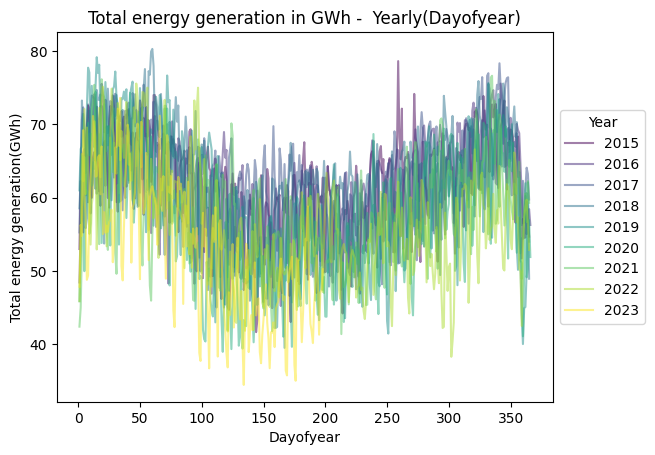

In [40]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [41]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [42]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')

In [43]:
#data_df.columns

In [44]:
df_c = data_df.copy()

In [45]:
#df_c.columns

In [46]:
def combine_date_and_time(df, date_column='Date', time_column='Hour', target_column=target):
    # Convert 'Date' column to datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Combine 'Date' and 'Hour' columns to create the 'Datetime' column
    df['Datetime'] = df.apply(lambda row: row[date_column] + pd.Timedelta(hours=row[time_column]), axis=1)
    
    # Select the desired columns for the final DataFrame
    df_result  = df[['Datetime', target_column]]
    
    return df_result

In [47]:
df_dt = combine_date_and_time(df_c, date_column='Date', time_column='Hour', target_column=target)

#### I need to write a function to include seasonality and trend information of data 

In [48]:
# Rolling mean
# window =
#df_dt[target]=data_df[target].rolling(window=365).mean() 
#df_dt = df_dt.dropna() #df_dt = df_dt.dropna(how='all')#(axis=0)
#df_dt = df_dt.dropna(axis=0)
# Reset index after drop
#df_dt=df_dt.dropna().reset_index(drop=True)
#df_dt.head()

In [49]:
df_dt.columns

Index(['Datetime', 'Total_energy_generation_gwh'], dtype='object')

In [50]:
df_dt.head()

,Datetime,Total_energy_generation_gwh
0,2015-01-01 00:00:00,51.45925
1,2015-01-01 01:00:00,49.98825
2,2015-01-01 02:00:00,49.26525
3,2015-01-01 03:00:00,48.53800
4,2015-01-01 04:00:00,48.63000


<Axes: xlabel='Datetime'>

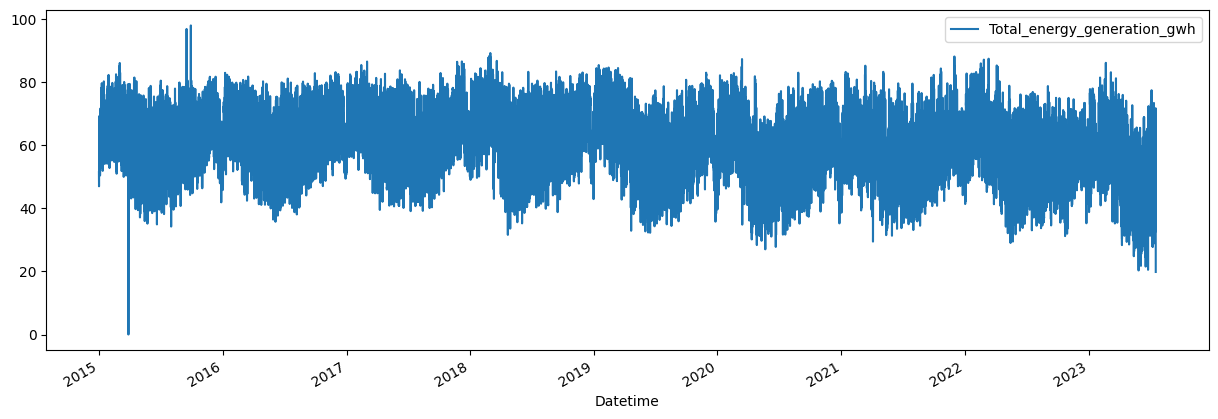

In [51]:

#df_c = data_df.copy()
#df_c = data_df[['Date',  target]]
df_dt = df_dt.set_index('Datetime')
df_dt.plot(style = '-', figsize = (15,5), color='#1f76b4')

In [52]:
#df_dt.loc[(df_dt.index > '2023-01-01') & (df_dt.index < '2023-12-01') ].plot(figsize=(15,5), ylabel=ylable_target, title= 'Data of last year', label = '2023 data')
#ax.legend(['2023 data'])
#plt.show()

In [53]:
def create_features(df):
    """
    create time series features based on time series index 
    """
    df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
   # df['Week'] = df.index.week
    df['Day'] = df.index.day
    #df['Dayofyear'] = df.index.dayofyear
    return df
#df_dt = create_features(df_dt)
#df_dt.head()

In [54]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.boxplot (data=df_dt, x= 'Hour', y =target)
#ax.set_title( title_main + '' + ' ' 'by hour')
#ax.set_ylabel(ylable_target)

In [55]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.boxplot (data=df_dt, x= 'Month', y =target)
#ax.set_title(title_main + '' + ' ' 'by month')
#ax.set_ylabel(ylable_target)

In [56]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.boxplot (data=df_dt, x= 'Day', y =target)
#ax.set_title(title_main + '' + ' ' 'by day')
#ax.set_ylabel(ylable_target)

In [57]:
dfs = data_df[['Date', target]]

In [58]:
df_dt.head()
#df_dt['Datetime'] = pd.to_datetime(df_dt['Datetime'])
#df_dt.set_index('Datetime', inplace=True)

,Total_energy_generation_gwh
Datetime,
2015-01-01 00:00:00,51.45925
2015-01-01 01:00:00,49.98825
2015-01-01 02:00:00,49.26525
2015-01-01 03:00:00,48.53800
2015-01-01 04:00:00,48.63000


In [59]:
dfs.head()

,Date,Total_energy_generation_gwh
0,2015-01-01,51.45925
1,2015-01-01,49.98825
2,2015-01-01,49.26525
3,2015-01-01,48.53800
4,2015-01-01,48.63000


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_81468/1283765561.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dfs[target])


Text(0.5, 1.0, 'Energy Distribution')

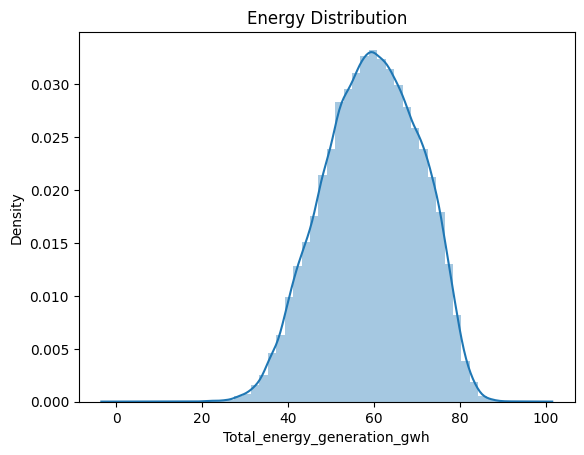

In [60]:
sns.distplot(dfs[target])
plt.title("Energy Distribution")
#sns.distplot(dfs['Solar_gwh'])
#plt.title("Solae Energy Distribution")

In [61]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [68]:

def average_lineplot_no_group_eng(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average total energy generation in Germany by month', ylabel= 'Total energy generation energy (GWh)');
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()


def average_lineplot_no_group_sol(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average solar energy generation in Germany by month', ylabel='Solar energy generation (GWh)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()

def average_lineplot_no_group_ren(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average other renewable energy generation in Germany by month', ylabel='Other renewable energy generation (GWh)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()   


def average_lineplot_no_group_Wind_onshore(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average wind onshore generation in Germany by month', ylabel='Wind onshore energy generation (GWh)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()   


def average_lineplot_no_group_Wind_offshore(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    #ax.set(title=y.replace('_', ' ').replace('gwh'), '', ylabel=ylable_target0);
    ax.set(title='Average wind offshore energy generation in Germany by month', ylabel='Wind offshore energy generation (GWh)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()  

#average_lineplot_no_group_Wind_onshore(df=data_df, y='Wind_onshore_gwh', x="Date", time='Month')
#average_lineplot_no_group_Wind_offshore(df=data_df, y= 'Wind_offshore_gwh', x="Date", time='Month')

#target = 'Total_energy_generation_gwh'
#target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh'



In [80]:
#average_lineplot_no_group_ren(df=data_df, y='Total_other_renewable_gwh', x="Date", time='Year')
#average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Year')
#average_lineplot_no_group_eng(df=data_df, y= 'Total_energy_generation_gwh', x="Date", time='Year')

In [81]:
#average_lineplot_no_group_ren(df=data_df, y='Total_other_renewable_gwh', x="Date", time='Month')
#average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Month')
#average_lineplot_no_group_eng(df=data_df, y= 'Total_energy_generation_gwh', x="Date", time='Month')

In [82]:
#average_lineplot_no_group_sol(df=data_df, y='Solar_gwh', x="Date", time='Month')
#average_lineplot_no_group_Wind_onshore(df=data_df, y='Wind_onshore_gwh', x="Date", time='Month')
#average_lineplot_no_group_Wind_offshore(df=data_df, y= 'Wind_offshore_gwh', x="Date", time='Month')

In [69]:
columns_to_keep= ['Date', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh', 'Total_energy_generation_gwh'] #'Total_other_renewable_gwh'
target = 'Total_energy_generation_gwh'
data_mlvt = data_df[columns_to_keep].copy()
data_mlvt.head()

,Date,Solar_gwh,Wind_onshore_gwh,Wind_offshore_gwh,Total_energy_generation_gwh
0,2015-01-01,0.0,8.84975,0.52100,51.45925
1,2015-01-01,0.0,9.04650,0.52075,49.98825
2,2015-01-01,0.0,9.19600,0.51900,49.26525
3,2015-01-01,0.0,9.14675,0.52250,48.53800
4,2015-01-01,0.0,9.20400,0.52425,48.63000


In [83]:
def average_lineplots(df, y_values, x='Date', time='Year'):
    fig, axes = plt.subplots(len(y_values), 1, figsize=(10, 5 * len(y_values)))

    for idx, y in enumerate(y_values):
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)

        ax = axes[idx]
        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')
        ax.set(title='', ylabel=y_label_target0)
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

#average_lineplots(df=data_df, y_values=['Total_energy_generation_gwh', 'Total_other_renewable_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')



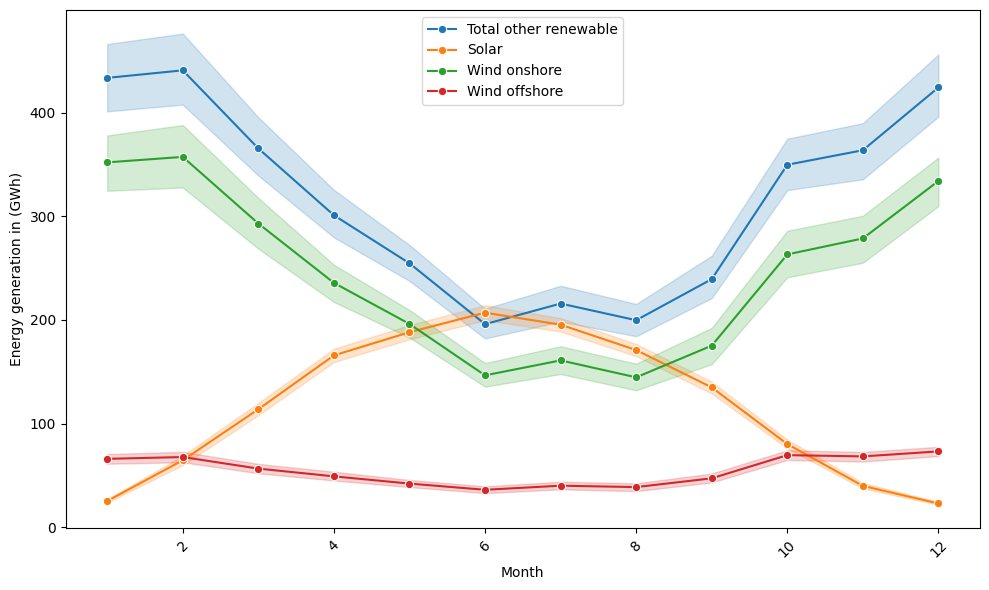

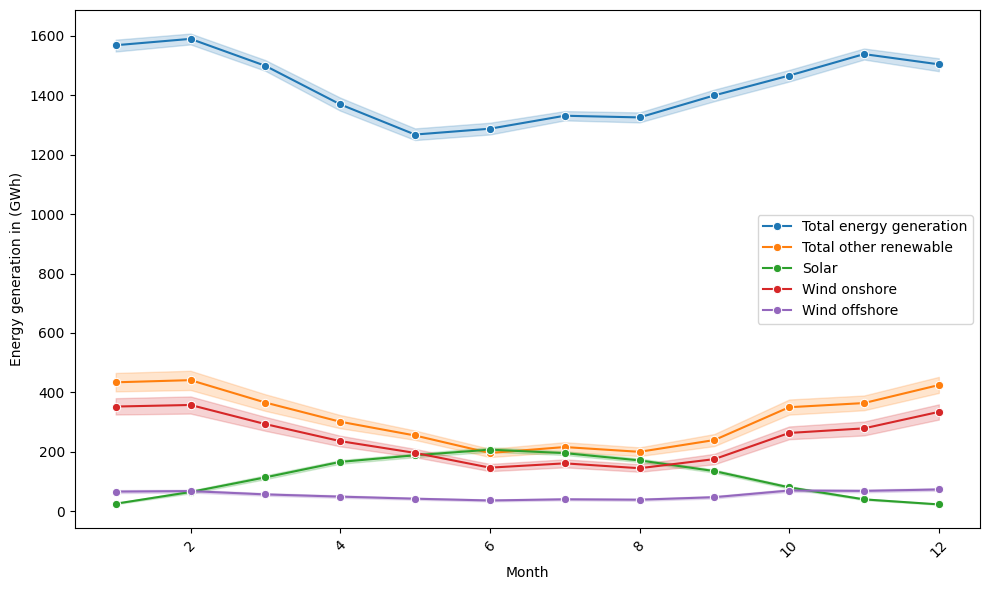

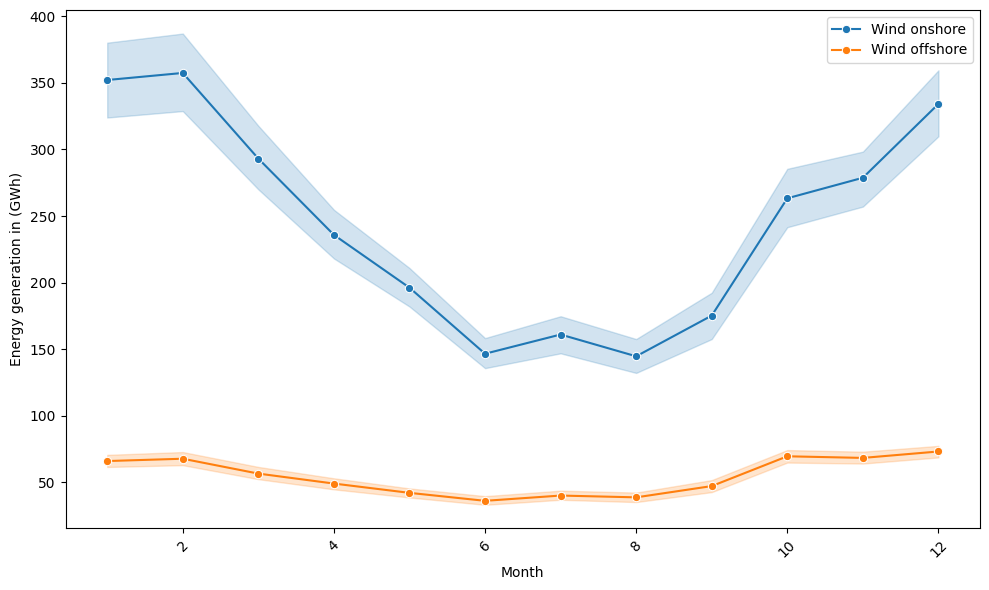

In [84]:
def average_lineplot_no_group(df, y_values, x='Date', time='Year'):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Energy generation in (GWh)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])

    plt.show()

average_lineplot_no_group(df=data_df, y_values=['Total_other_renewable_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')   
average_lineplot_no_group(df=data_df, y_values=['Total_energy_generation_gwh', 'Total_other_renewable_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')
average_lineplot_no_group(df=data_df, y_values=['Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')

#### Multivariate LSTM

#### Working code

In [85]:
columns_to_keep= ['Date', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh', 'Total_energy_generation_gwh'] #'Total_other_renewable_gwh'
target = 'Total_energy_generation_gwh'
features= ['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh', 'Total_energy_generation_gwh']
data_mlvt = data_df[columns_to_keep].copy()

data_mlvt.head()

,Date,Solar_gwh,Wind_onshore_gwh,Wind_offshore_gwh,Total_energy_generation_gwh
0,2015-01-01,0.0,8.84975,0.52100,51.45925
1,2015-01-01,0.0,9.04650,0.52075,49.98825
2,2015-01-01,0.0,9.19600,0.51900,49.26525
3,2015-01-01,0.0,9.14675,0.52250,48.53800
4,2015-01-01,0.0,9.20400,0.52425,48.63000


In [86]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback, :-1])
        y.append(data[i+lookback, -1])
    return np.array(X), np.array(y)

def lstm_mlvrt(target, data_df, features, lookback=12, sampling_frequency='M', rolling_mean=None, detrend=False, moving_average=False, ma_window=None):
    # Prepare the input data
    target_label = target.replace('_gwh', ' (GWh)').replace('_', ' ')
    main_target = target.replace('_', ' ').replace('gwh', '(monthly)')
    
    if sampling_frequency:
        data_df['Date'] = pd.to_datetime(data_df['Date'])
        data_df.set_index('Date', inplace=True)
        dfs_resampled = data_df[features + [target]].resample(sampling_frequency).mean()
    else:
        dfs_resampled = data_df[features + [target]]
    
    if rolling_mean:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=rolling_mean, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    if detrend:
        result = seasonal_decompose(dfs_resampled[target], model='additive', period=12)
        dfs_resampled[target] = dfs_resampled[target] - result.trend
        dfs_resampled[target] = dfs_resampled[target].fillna(method='bfill')
    
    if moving_average:
        for feature in features + [target]:
            dfs_resampled[feature] = dfs_resampled[feature].rolling(window=ma_window, min_periods=1, center=True).mean()
            dfs_resampled[feature] = dfs_resampled[feature].fillna(method='bfill')
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(dfs_resampled.values)
    
    X_lstm, y_lstm = create_sequences(data_scaled, lookback)
    
    train_size = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
    y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]
    
    # Build the LSTM model
    model = Sequential()
    model.add(LSTM(units=64, activation='relu', input_shape=(lookback, len(features)), return_sequences=True))
    model.add(LSTM(units=32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=5, validation_data=(X_test_lstm, y_test_lstm), verbose=1)
    
    # LSTM prediction on test and train data
    y_pred_train_lstm = model.predict(X_train_lstm)
    y_pred_test_lstm = model.predict(X_test_lstm)
    
    # Inverse transform the scaled data to get the original scale
    y_pred_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_pred_train_lstm)))
    y_pred_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_pred_test_lstm)))
    y_train_lstm = scaler.inverse_transform(np.hstack((X_train_lstm[:, -1, :], y_train_lstm.reshape(-1, 1))))
    y_test_lstm = scaler.inverse_transform(np.hstack((X_test_lstm[:, -1, :], y_test_lstm.reshape(-1, 1))))
    
    # Compute metrics for LSTM
    train_rmse = np.sqrt(mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1]))
    test_rmse = np.sqrt(mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1]))
    train_mse = mean_squared_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mse = mean_squared_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_mae = mean_absolute_error(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_mae = mean_absolute_error(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    train_r2 = r2_score(y_train_lstm[:, -1], y_pred_train_lstm[:, -1])
    test_r2 = r2_score(y_test_lstm[:, -1], y_pred_test_lstm[:, -1])
    
    # Calculate residuals
    residuals = y_test_lstm[:, -1] - y_pred_test_lstm[:, -1]

    print("Train RMSE:", train_rmse)
    print("Train MSE:", train_mse)
    print("Train MAE:", train_mae)
    print("Train R2 Score:", train_r2)
    print("Test RMSE:", test_rmse)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    print("Test R2 Score:", test_r2)

    
    # Plot loss versus epoch and validation loss versus epoch
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss from history')
    plt.title('Loss vs. Epoch')
    plt.legend()
    plt.show()
    
    # Create a residual plot
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test_lstm[:, -1], residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('True Values')
    plt.ylabel('Residuals')
    plt.title(main_target)
    plt.show()
    
    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test_lstm[:, -1], y_pred_test_lstm[:, -1], label='', color='blue')
    plt.plot([y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], [y_test_lstm[:, -1].min(), y_test_lstm[:, -1].max()], 'k--', lw=2, label='')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(main_target)
    plt.show()
    
    # Plot actual, train data, and predicted test data for LSTM
    plt.figure(figsize=(15, 5))
    train_index = dfs_resampled.index[:train_size][-len(y_train_lstm):]
    test_index = dfs_resampled.index[-len(y_test_lstm):]  # Ensure test_index and y_test_lstm have the same length
    plt.plot(dfs_resampled.index, dfs_resampled[target], label='Historical Data', color='gray')
    plt.plot(train_index, y_train_lstm[:, -1], label='Train Data', color='blue')
    plt.plot(test_index, y_test_lstm[:, -1], label='Test Data', color='#1f76b4')
    plt.plot(test_index, y_pred_test_lstm[:, -1], label='Predicted Test Data', color='red')
    plt.plot(train_index, y_pred_train_lstm[:, -1], label='Predicted Train Data', color='green', linestyle='dashed')
    plt.legend()
    plt.title(main_target)
    plt.ylabel(target_label)
    plt.xlabel('Date')
    plt.show()
    
    #print('X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape =', X_train_lstm.shape, X_test_lstm.shape, y_train_lstm.shape, y_test_lstm.shape, X_lstm.shape, y_lstm.shape, dfs_resampled.shape)

    return {
        'train_rmse': train_rmse,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'residuals': residuals,
        'y_test_predicted': y_pred_test_lstm,
        'model': model,
        'X_train_lstm': X_train_lstm,
        'X_test_lstm': X_test_lstm
    }


In [217]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [218]:
columns_to_keep= ['Date', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh', 'Total_energy_generation_gwh'] #'Total_other_renewable_gwh'
#target = 'Total_energy_generation_gwh'
data_mlvt = data_df[columns_to_keep].copy()
data_mlvt.head()

,Date,Solar_gwh,Wind_onshore_gwh,Wind_offshore_gwh,Total_energy_generation_gwh
0,2015-01-01,0.0,8.84975,0.52100,51.45925
1,2015-01-01,0.0,9.04650,0.52075,49.98825
2,2015-01-01,0.0,9.19600,0.51900,49.26525
3,2015-01-01,0.0,9.14675,0.52250,48.53800
4,2015-01-01,0.0,9.20400,0.52425,48.63000


In [150]:
#data = data_df.copy()
target = 'Total_energy_generation_gwh'
features = ['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh']  # You can add other features if needed, 
result = lstm_mlvrt(target, data_mlvt, features=features, lookback=12, sampling_frequency= 'M',
                    rolling_mean=None, detrend=False, moving_average=False, ma_window=None)

KeyError: "['Total_other_renewable_gwh'] not in index"

,Date,Solar_gwh,Wind_onshore_gwh,Wind_offshore_gwh,Total_energy_generation_gwh
0,2015-01-01,0.0,8.84975,0.52100,51.45925
1,2015-01-01,0.0,9.04650,0.52075,49.98825
2,2015-01-01,0.0,9.19600,0.51900,49.26525
3,2015-01-01,0.0,9.14675,0.52250,48.53800
4,2015-01-01,0.0,9.20400,0.52425,48.63000


NameError: name 'build_lstm_model' is not defined